# M2 — Agent Layer Demo

End-of-milestone demonstration: all three agents (news sentiment, macro regime, Polymarket events)
plus the full aggregation pipeline across five historical dates.

## Prerequisites
```bash
uv run python scripts/init_db.py
uv run python scripts/ingest_prices.py
uv run python scripts/ingest_macro.py
uv run python scripts/ingest_alpha_vantage_news.py  # historical backfill
uv run python scripts/ingest_polymarket.py
```

## Sections
1. **Run NewsAgent** — news sentiment signals for one week
2. **Sentiment bar chart** — per-sector scores
3. **Run MacroAgent** — regime classification + rate outlook
4. **Macro regime timeline** — classified regime across the backtest window
5. **Run PolymarketAgent** — sector tilts driven by prediction markets
6. **Polymarket tilt chart** — sector tilts + driving events
7. **All signals table** — every signal row in SQLite
8. **Full pipeline run** — one-call entrypoint for all agents + aggregator
9. **Five historical dates** — pipeline across distinct market conditions
10. **Sanity check: regime vs VIX** — do risk-off labels align with elevated VIX?
11. **Sanity check: sentiment vs returns** — do news signals weakly predict next-week returns?
12. **Cost analysis** — per-run breakdown + backtest projection + cache hit rate

In [1]:
import datetime
import logging
import sys
from pathlib import Path

sys.path.insert(0, str(Path('..') / 'src'))

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from IPython.display import display
from sqlalchemy import create_engine, text

logging.basicConfig(level=logging.INFO, format='%(levelname)s %(name)s: %(message)s')

DB_PATH = Path('..') / 'data' / 'state.db'
engine = create_engine(f'sqlite:///{DB_PATH}')

ANALYSIS_DATE = datetime.date(2026, 6, 13)

SECTOR_NAMES = {
    'XLK': 'Technology',          'XLF': 'Financials',
    'XLV': 'Health Care',         'XLY': 'Consumer Discretionary',
    'XLP': 'Consumer Staples',    'XLE': 'Energy',
    'XLI': 'Industrials',         'XLB': 'Materials',
    'XLRE': 'Real Estate',        'XLU': 'Utilities',
}

print(f'Analysis date : {ANALYSIS_DATE}')
print(f'DB path       : {DB_PATH.resolve()}')

Analysis date : 2026-06-13
DB path       : /Users/meghagarwal/Downloads/ai-trading-portfolio/data/state.db


## Section 1 — Run NewsAgent

Queries `news_raw` for the trailing 7 days, calls `claude-haiku-4-5-20251001` (cached on repeat),
writes 10 signal rows to `signals`.

In [2]:
from agents.news_agent import NewsAgent

news_agent = NewsAgent()
news_input = news_agent.prepare_input(ANALYSIS_DATE, engine)
coverage = {etf: len(articles) for etf, articles in news_input['sectors'].items()}
total_articles = sum(coverage.values())

print(f'Article coverage for week {news_input["week_start"]} → {news_input["analysis_date"]}:')
for etf, n in sorted(coverage.items()):
    print(f'  {etf:5s}  {n:3d}  {"█" * min(n, 20)}')
print(f'\nTotal: {total_articles} articles')

if total_articles == 0:
    print('\n⚠  No news — run ingest_alpha_vantage_news.py first.')
    news_result = None
else:
    news_result = news_agent.run(ANALYSIS_DATE, engine)
    avg_conv = sum(news_result["sector_conviction"].values()) / max(len(news_result["sector_conviction"]), 1)
    print(f'\n✓ NewsAgent done  avg_conviction={avg_conv:.2f}')
    print(f'  key_themes: {news_result["key_themes"]}')

INFO agents.news_agent: prepare_input date=2026-06-13  total_articles=200  sectors=10
INFO agents.news_agent: prepare_input date=2026-06-13  total_articles=200  sectors=10
INFO cache: agent=sentiment            model=claude-haiku-4-5-20251001      cached=True   in=    0 out=    0  cost=$0.00000  latency=0ms
INFO agents.news_agent: Wrote 10 signal rows  date=2026-06-13  agent=sentiment  avg_conviction=0.55


Article coverage for week 2026-06-06 → 2026-06-13:
  XLB     20  ████████████████████
  XLE     20  ████████████████████
  XLF     20  ████████████████████
  XLI     20  ████████████████████
  XLK     20  ████████████████████
  XLP     20  ████████████████████
  XLRE    20  ████████████████████
  XLU     20  ████████████████████
  XLV     20  ████████████████████
  XLY     20  ████████████████████

Total: 200 articles

✓ NewsAgent done  avg_conviction=0.55
  key_themes: ['AI infrastructure capex cycle driving GPU and power demand', 'Data center energy demand reshaping utility and power generation strategy', 'Geopolitical de-escalation (Iran peace signals) pressuring oil prices', 'Healthcare innovation accelerating with clinical wins and M&A activity', 'Memory supply constraints emerging as structural AI cost headwind']


## Section 2 — Sentiment bar chart

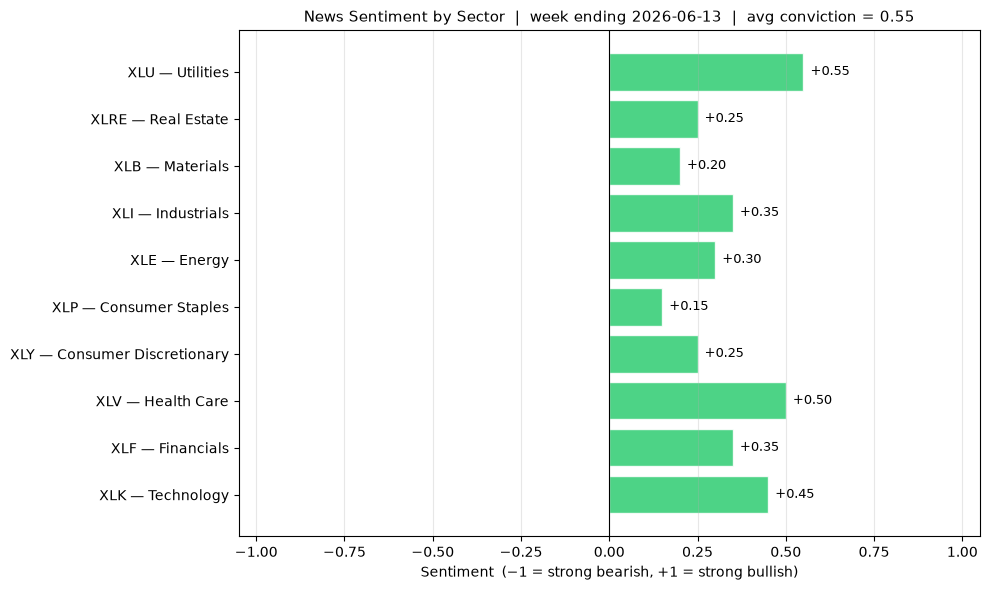

Key themes:
  1. AI infrastructure capex cycle driving GPU and power demand
  2. Data center energy demand reshaping utility and power generation strategy
  3. Geopolitical de-escalation (Iran peace signals) pressuring oil prices
  4. Healthcare innovation accelerating with clinical wins and M&A activity
  5. Memory supply constraints emerging as structural AI cost headwind


In [3]:
if news_result is None:
    print('⚠  No result to plot.')
else:
    sentiments = news_result['sector_sentiments']
    labels = [f'{etf} — {SECTOR_NAMES.get(etf, etf)}' for etf in sentiments]
    scores = list(sentiments.values())
    colors = ['#2ecc71' if s > 0.05 else '#e74c3c' if s < -0.05 else '#bdc3c7' for s in scores]

    avg_conv = sum(news_result["sector_conviction"].values()) / max(len(news_result["sector_conviction"]), 1)

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(labels, scores, color=colors, alpha=0.85, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlim(-1.05, 1.05)
    ax.set_xlabel('Sentiment  (−1 = strong bearish, +1 = strong bullish)', fontsize=10)
    ax.set_title(
        f'News Sentiment by Sector  |  week ending {ANALYSIS_DATE}  '
        f'|  avg conviction = {avg_conv:.2f}', fontsize=11)
    for bar, score in zip(bars, scores):
        ha = 'left' if score >= 0 else 'right'
        ax.text(score + (0.02 if score >= 0 else -0.02),
                bar.get_y() + bar.get_height() / 2,
                f'{score:+.2f}', va='center', ha=ha, fontsize=9)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print('Key themes:')
    for i, t in enumerate(news_result['key_themes'], 1):
        print(f'  {i}. {t}')

## Section 3 — Run MacroAgent

Pulls 30 days of FRED series, computes derived features, adds XLF+XLI news digest,
calls `claude-sonnet-4-6` with chain-of-thought reasoning.

In [4]:
from agents.macro_agent import MacroAgent

macro_agent = MacroAgent()
macro_input = macro_agent.prepare_input(ANALYSIS_DATE, engine)

n_digest_articles = sum(len(v) for v in macro_input['macro_news_digest'].values())
n_features = len(macro_input['derived_features'])
print(f'Derived features: {n_features}  |  macro news digest articles (XLF+XLI): {n_digest_articles}')

if macro_input['derived_features']:
    print('\nKey derived features:')
    for k, v in macro_input['derived_features'].items():
        print(f'  {k:<30s} {v}')

if n_features == 0:
    print('\n⚠  No macro data — run ingest_macro.py first.')
    macro_result = None
else:
    macro_result = macro_agent.run(ANALYSIS_DATE, engine)
    print(f'\n✓ MacroAgent done')
    print(f'  regime      : {macro_result["regime"]}')
    print(f'  rate_outlook: {macro_result["rate_outlook"]}')
    print(f'  confidence  : {macro_result["confidence"]:.2f}')
    print(f'\nRationale: {macro_result["rationale"]}')
    print(f'\nReasoning (excerpt):\n  {macro_result["reasoning"][:400]}...')

INFO agents.macro_agent: prepare_input date=2026-06-13  macro_rows=2807  news_articles=13
INFO agents.macro_agent: prepare_input date=2026-06-13  macro_rows=2807  news_articles=13
INFO cache: agent=macro                model=claude-sonnet-4-6              cached=True   in=    0 out=    0  cost=$0.00000  latency=0ms
INFO agents.macro_agent: Wrote 2 signal rows  date=2026-06-13  regime=risk_on  rate_outlook=stable  confidence=0.72


Derived features: 16  |  macro news digest articles (XLF+XLI): 13

Key derived features:
  vix_current                    17.68
  vix_30d_change                 0.42
  vix_90d_avg                    20.12
  t10y2y_current                 0.39
  t10y2y_90d_avg                 0.49
  t10y2y_vs_90d_avg              -0.1
  dgs10_current                  4.48
  dgs10_30d_change               0.01
  cpi_current                    333.979
  cpi_yoy_pct                    3.9
  unrate_current                 4.3
  unrate_3m_change               0.0
  icsa_current                   226000
  icsa_4w_avg                    219482
  usd_index_current              119.51
  usd_index_30d_change           0.84

✓ MacroAgent done
  regime      : risk_on
  rate_outlook: stable
  confidence  : 0.72

Rationale: The macro backdrop is constructively risk-on: VIX at 17.68 sits well below its 90-day average of 20.12, the yield curve has fully normalized to +39bps (no recession signal), and labour market cond

## Section 4 — Macro regime timeline

Populated after running MacroAgent across multiple dates. See loop example in the cell.

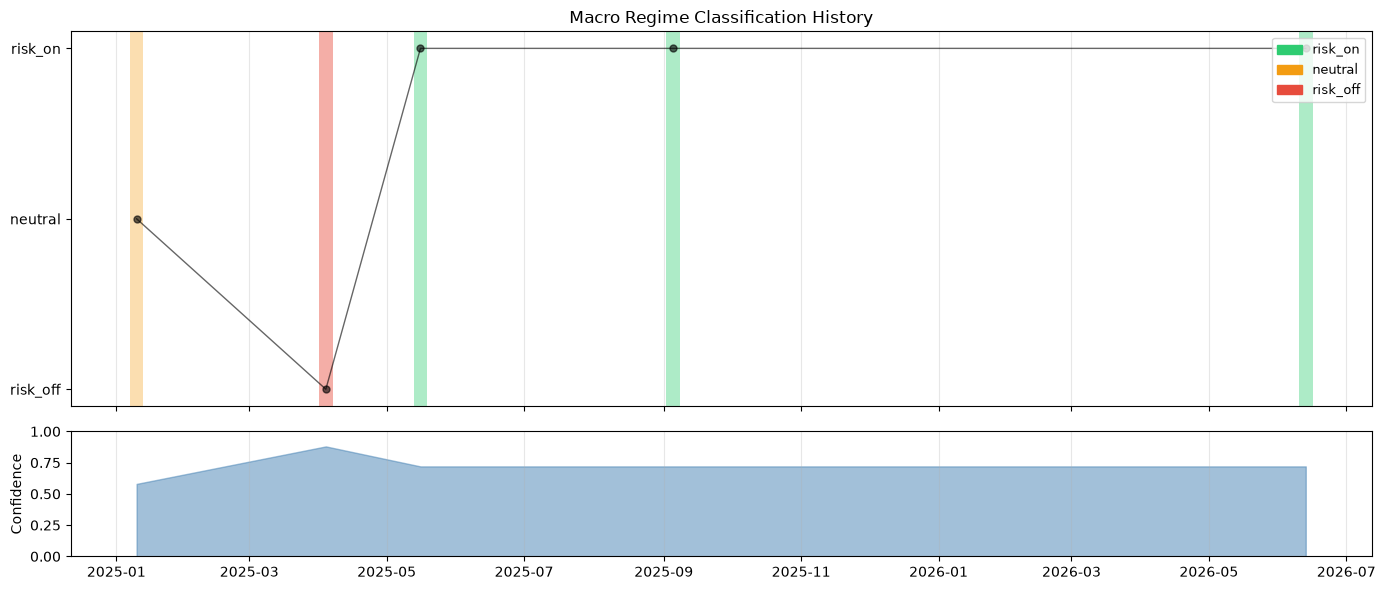

,Date,Regime,Rate Outlook,Confidence
0,2025-01-10,neutral,▲ rising,0.58
1,2025-04-04,risk_off,▼ falling,0.88
2,2025-05-16,risk_on,─ stable,0.72
3,2025-09-05,risk_on,▼ falling,0.72
4,2026-06-13,risk_on,─ stable,0.72


In [5]:
regime_df = pd.read_sql(
    text("""
        SELECT s.date, s.signal_value, s.confidence,
               r.signal_value as rate_val
        FROM signals s
        LEFT JOIN signals r ON r.date = s.date AND r.agent_name = 'macro' AND r.target = 'rate_outlook'
        WHERE s.agent_name = 'macro' AND s.target = 'macro_regime'
        ORDER BY s.date
    """),
    engine, parse_dates=['date'],
)

if regime_df.empty:
    print('⚠  No regime signals yet. To populate, run:')
    print('   from agents.macro_agent import MacroAgent')
    print('   agent = MacroAgent()')
    print('   for d in pd.date_range("2025-01-10", "2026-06-13", freq="W-FRI"):')
    print('       agent.run(d.date(), engine)')
else:
    REGIME_COLORS = {1.0: '#2ecc71', 0.0: '#f39c12', -1.0: '#e74c3c'}
    REGIME_LABELS = {1.0: 'risk_on', 0.0: 'neutral', -1.0: 'risk_off'}

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True,
                                    gridspec_kw={'height_ratios': [3, 1]})
    for _, row in regime_df.iterrows():
        color = REGIME_COLORS.get(row['signal_value'], '#95a5a6')
        ax1.axvspan(row['date'] - pd.Timedelta(days=3), row['date'] + pd.Timedelta(days=3),
                    alpha=0.4 * row['confidence'] + 0.1, color=color, linewidth=0)
    ax1.plot(regime_df['date'], regime_df['signal_value'], 'o-', color='black', markersize=5, linewidth=1, alpha=0.6)
    ax1.set_yticks([-1, 0, 1]); ax1.set_yticklabels(['risk_off', 'neutral', 'risk_on'])
    ax1.set_title('Macro Regime Classification History', fontsize=12); ax1.grid(axis='x', alpha=0.3)
    patches = [mpatches.Patch(color=c, label=l) for v, c in REGIME_COLORS.items() for lv, l in REGIME_LABELS.items() if lv == v]
    ax1.legend(handles=patches, loc='upper right', fontsize=9)
    ax2.fill_between(regime_df['date'], regime_df['confidence'], alpha=0.5, color='steelblue')
    ax2.set_ylim(0, 1); ax2.set_ylabel('Confidence'); ax2.grid(axis='x', alpha=0.3)
    plt.tight_layout(); plt.show()

    regime_df['regime'] = regime_df['signal_value'].map(REGIME_LABELS)
    regime_df['rate'] = regime_df['rate_val'].map({1.0: '▲ rising', 0.0: '─ stable', -1.0: '▼ falling'})
    display(regime_df[['date', 'regime', 'rate', 'confidence']]
            .assign(date=regime_df['date'].dt.strftime('%Y-%m-%d'))
            .rename(columns={'date': 'Date', 'regime': 'Regime', 'rate': 'Rate Outlook', 'confidence': 'Confidence'}))

## Section 5 — Run PolymarketAgent

Reads current implied probabilities from `polymarket_raw`, fetches 30-day trend,
applies sector-impact mappings from `config/polymarket_markets.yaml`,
calls `claude-haiku-4-5-20251001` to compute aggregate sector tilts.

In [6]:
from agents.polymarket_agent import PolymarketAgent

poly_agent = PolymarketAgent()
poly_input = poly_agent.prepare_input(ANALYSIS_DATE, engine)

markets = poly_input['markets']
n_with_data = sum(1 for m in markets if m['current_prob'] is not None)

print(f'Curated markets : {len(markets)}')
print(f'With DB data    : {n_with_data}')
print()

for m in markets:
    prob_str = f"{m['current_prob']:.2f}" if m['current_prob'] is not None else 'n/a '
    trend_str = ''
    if m['current_prob'] is not None and m['prob_30d_ago'] is not None:
        delta = m['current_prob'] - m['prob_30d_ago']
        trend_str = f'  Δ30d={delta:+.2f}'
    vol_str = f"${m['volume_usd']/1e3:.0f}k" if m['volume_usd'] else '—'
    days_str = f"{m['days_to_resolution']}d" if m['days_to_resolution'] is not None else '—'
    print(f"  [{m['confidence_rating']:6s}] p={prob_str}{trend_str}  vol={vol_str:7s}  tte={days_str:6s}  {m['question'][:60]}")

if n_with_data == 0:
    print('\n⚠  No Polymarket data — run ingest_polymarket.py first.')
    poly_result = None
else:
    poly_result = poly_agent.run(ANALYSIS_DATE, engine)
    print(f'\n✓ PolymarketAgent done  confidence={poly_result["overall_confidence"]:.2f}  horizon={poly_result["time_horizon"]}')

INFO agents.polymarket_agent: prepare_input date=2026-06-13  markets_with_data=13/13
INFO agents.polymarket_agent: prepare_input date=2026-06-13  markets_with_data=13/13
INFO cache: agent=events               model=claude-haiku-4-5-20251001      cached=True   in=    0 out=    0  cost=$0.00000  latency=0ms
INFO agents.polymarket_agent: Wrote 10 signal rows  date=2026-06-13  agent=events  confidence=0.58


Curated markets : 13
With DB data    : 13

  [high  ] p=0.03  Δ30d=+0.00  vol=$117k    tte=4d      Fed rate cut by July 2026 meeting?
  [high  ] p=0.02  Δ30d=+0.00  vol=$1283k   tte=201d    Will 3 fed rate cuts happen in 2026?
  [medium] p=0.40  Δ30d=+0.00  vol=$131k    tte=201d    Jerome Powell out from Fed Board by December 31?
  [high  ] p=0.17  Δ30d=+0.00  vol=$1552k   tte=232d    US recession by end of 2026?
  [medium] p=0.77  Δ30d=+0.00  vol=$4974k   tte=201d    Will no Fed rate cuts happen in 2026?
  [medium] p=0.17  Δ30d=+0.00  vol=$113k    tte=-154d   Will US unemployment reach at least 5.0% in 2026?
  [medium] p=0.19  Δ30d=+0.00  vol=$136k    tte=201d    Will Crude Oil reach a new all-time high by December 31?
  [medium] p=0.01  Δ30d=+0.00  vol=$63k     tte=17d     100% tariff on Canada in effect by June 30?
  [low   ] p=0.28  Δ30d=+0.00  vol=$2221k   tte=201d    Ukraine signs peace deal with Russia before 2027?
  [low   ] p=0.06  Δ30d=+0.00  vol=$34279k  tte=201d    Will Chi

## Section 6 — Polymarket tilt chart

Aggregate sector tilt scores from all Polymarket events, with driving events annotated.

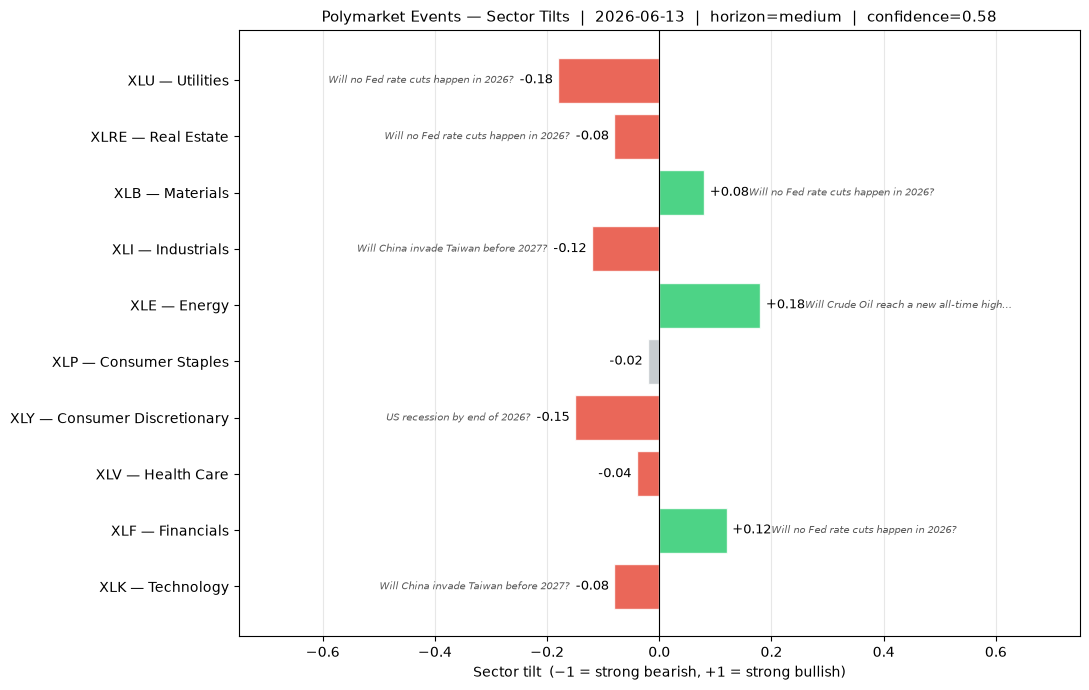


Driving events per sector:
  XLB   (+0.08):
    • Will no Fed rate cuts happen in 2026?
  XLE   (+0.18):
    • Will Crude Oil reach a new all-time high by December 31?
  XLF   (+0.12):
    • Will no Fed rate cuts happen in 2026?
  XLI   (-0.12):
    • Will China invade Taiwan before 2027?
  XLK   (-0.08):
    • Will China invade Taiwan before 2027?
  XLP   (-0.02):
    (no driving events)
  XLRE  (-0.08):
    • Will no Fed rate cuts happen in 2026?
  XLU   (-0.18):
    • Will no Fed rate cuts happen in 2026?
  XLV   (-0.04):
    (no driving events)
  XLY   (-0.15):
    • US recession by end of 2026?


In [7]:
if poly_result is None:
    print('⚠  No Polymarket result to plot.')
else:
    impacts = poly_result['sector_tilts']
    # Convert list[{sector, market_question, reasoning}] → dict[sector, list[str]]
    driving_by_sector: dict[str, list[str]] = {}
    for ev in poly_result['driving_events']:
        sec = ev.get('sector', '')
        question = ev.get('market_question', ev.get('reasoning', ''))
        driving_by_sector.setdefault(sec, []).append(question)

    etfs   = list(impacts.keys())
    tilts  = list(impacts.values())
    labels = [f'{etf} — {SECTOR_NAMES.get(etf, etf)}' for etf in etfs]
    colors = ['#2ecc71' if t > 0.02 else '#e74c3c' if t < -0.02 else '#bdc3c7' for t in tilts]

    fig, ax = plt.subplots(figsize=(11, 7))
    bars = ax.barh(labels, tilts, color=colors, alpha=0.85, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlim(-0.75, 0.75)
    ax.set_xlabel('Sector tilt  (−1 = strong bearish, +1 = strong bullish)', fontsize=10)
    ax.set_title(
        f'Polymarket Events — Sector Tilts  |  {ANALYSIS_DATE}  '
        f'|  horizon={poly_result["time_horizon"]}  '
        f'|  confidence={poly_result["overall_confidence"]:.2f}',
        fontsize=11)

    for bar, etf, tilt in zip(bars, etfs, tilts):
        ha = 'left' if tilt >= 0 else 'right'
        ax.text(tilt + (0.01 if tilt >= 0 else -0.01),
                bar.get_y() + bar.get_height() / 2,
                f'{tilt:+.2f}', va='center', ha=ha, fontsize=9)
        events = driving_by_sector.get(etf, [])
        if events:
            short = events[0][:40] + ('…' if len(events[0]) > 40 else '')
            x_pos = tilt + (0.08 if tilt >= 0 else -0.08)
            ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
                    short, va='center', ha=ha, fontsize=7, alpha=0.65,
                    style='italic')

    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print('\nDriving events per sector:')
    for etf in sorted(impacts.keys()):
        tilt = impacts.get(etf, 0)
        events = driving_by_sector.get(etf, [])
        print(f'  {etf:5s} ({tilt:+.2f}):')
        for e in events:
            print(f'    • {e}')
        if not events:
            print(f'    (no driving events)')

## Section 7 — All signals in DB

## Section 8 — Full pipeline run

`run_agent_pipeline` runs all three agents then the aggregator in one call.
Failed agents are replaced with neutral (zero) stubs — the pipeline never crashes
on a single agent error.

INFO agents.pipeline: === run_agent_pipeline  date=2026-06-13 ===
INFO agents.news_agent: prepare_input date=2026-06-13  total_articles=200  sectors=10
INFO cache: agent=sentiment            model=claude-haiku-4-5-20251001      cached=True   in=    0 out=    0  cost=$0.00000  latency=0ms
INFO agents.news_agent: Wrote 10 signal rows  date=2026-06-13  agent=sentiment  avg_conviction=0.55
INFO agents.pipeline: Agent sentiment succeeded  latency=19ms
INFO agents.macro_agent: prepare_input date=2026-06-13  macro_rows=2807  news_articles=13
INFO cache: agent=macro                model=claude-sonnet-4-6              cached=True   in=    0 out=    0  cost=$0.00000  latency=0ms
INFO agents.macro_agent: Wrote 2 signal rows  date=2026-06-13  regime=risk_on  rate_outlook=stable  confidence=0.72
INFO agents.pipeline: Agent macro succeeded  latency=65ms
INFO agents.polymarket_agent: prepare_input date=2026-06-13  markets_with_data=13/13
INFO cache: agent=events               model=claude-haiku-4-5-2

Pipeline date : 2026-06-13
Total cost    : $0.00000
Total latency : 104 ms

Agent status:
  sentiment    ✓  19 ms
  macro        ✓  65 ms
  events       ✓  4 ms

Black-Litterman views (Q = annual expected excess return):
  XLK    Q=+0.00515  Ω=0.0080  ▲ ██
  XLF    Q=+0.00524  Ω=0.0083  ▲ ██
  XLV    Q=+0.00665  Ω=0.0078  ▲ ██
  XLY    Q=+0.00120  Ω=0.0088  ▲ 
  XLP    Q=+0.00088  Ω=0.0098  ▲ 
  XLE    Q=+0.00487  Ω=0.0085  ▲ █
  XLI    Q=+0.00246  Ω=0.0088  ▲ 
  XLB    Q=+0.00230  Ω=0.0095  ▲ 
  XLRE   Q=+0.00155  Ω=0.0091  ▲ 
  XLU    Q=+0.00668  Ω=0.0075  ▲ ██


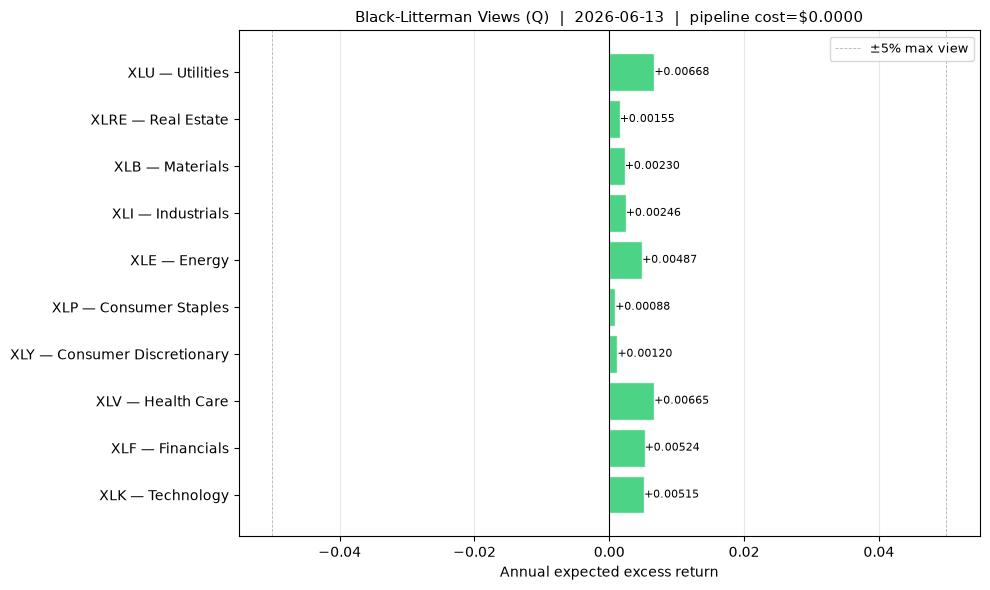

In [8]:
from agents.pipeline import run_agent_pipeline

pipeline_result = run_agent_pipeline(ANALYSIS_DATE, engine)

# ── Agent status ──────────────────────────────────────────────────────────────
print(f'Pipeline date : {pipeline_result["date"]}')
print(f'Total cost    : ${pipeline_result["total_cost_usd"]:.5f}')
print(f'Total latency : {pipeline_result["total_latency_ms"]:.0f} ms')
print()
print('Agent status:')
for name, info in pipeline_result['signals_by_agent'].items():
    status = info['status']
    latency = info.get('latency_ms', 0)
    if status == 'ok':
        print(f'  {name:<12s} ✓  {latency:.0f} ms')
    else:
        print(f'  {name:<12s} ✗  {latency:.0f} ms  ERROR: {info["error"][:80]}')

# ── Views (Q vector) ──────────────────────────────────────────────────────────
print()
print('Black-Litterman views (Q = annual expected excess return):')
sectors = list(SECTOR_NAMES.keys())
q_values = pipeline_result['views']['q']
omega_diag = pipeline_result['views']['omega_diag']

max_annual = 0.05  # Q is now in annual units (ADR-020)
for etf, q, omega in zip(sectors, q_values, omega_diag):
    bar_len = int(abs(q) / max_annual * 20)  # scale: max annual = 20 chars
    bar = ('█' * bar_len) if q >= 0 else ('░' * bar_len)
    direction = '▲' if q > 1e-6 else '▼' if q < -1e-6 else '─'
    print(f'  {etf:5s}  Q={q:+.5f}  Ω={omega:.4f}  {direction} {bar}')

# ── Views chart ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ecc71' if q > 1e-6 else '#e74c3c' if q < -1e-6 else '#bdc3c7' for q in q_values]
labels = [f'{etf} — {SECTOR_NAMES[etf]}' for etf in sectors]
bars = ax.barh(labels, q_values, color=colors, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)

# Mark ±5% annual as reference lines (max possible view magnitude)
ax.axvline(max_annual, color='grey', linewidth=0.6, linestyle='--', alpha=0.6, label='±5% max view')
ax.axvline(-max_annual, color='grey', linewidth=0.6, linestyle='--', alpha=0.6)

for bar, q in zip(bars, q_values):
    if abs(q) > 1e-6:
        ha = 'left' if q >= 0 else 'right'
        ax.text(q + (1e-5 if q >= 0 else -1e-5), bar.get_y() + bar.get_height() / 2,
                f'{q:+.5f}', va='center', ha=ha, fontsize=8)

ax.set_xlabel('Annual expected excess return', fontsize=10)
ax.set_title(
    f'Black-Litterman Views (Q)  |  {pipeline_result["date"]}  '
    f'|  pipeline cost=${pipeline_result["total_cost_usd"]:.4f}',
    fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
all_sig_df = pd.read_sql(
    text("""
        SELECT s.date, s.agent_name, s.target, s.signal_value, s.confidence,
               a.model_string, a.cached, a.cost_usd, a.latency_ms
        FROM signals s
        LEFT JOIN agent_calls a ON s.raw_call_id = a.call_id
        ORDER BY s.date DESC, s.agent_name, s.target
    """),
    engine,
)

if all_sig_df.empty:
    print('⚠  No signals in DB yet.')
else:
    all_sig_df['signal_value'] = all_sig_df['signal_value'].round(3)
    all_sig_df['cost_usd'] = all_sig_df['cost_usd'].map(lambda x: f'${x:.5f}' if pd.notna(x) else '—')
    all_sig_df['latency_ms'] = all_sig_df['latency_ms'].map(lambda x: f'{x:.0f}ms' if pd.notna(x) else '—')
    all_sig_df['cached'] = all_sig_df['cached'].map(lambda x: '✓' if x else '✗')
    display(all_sig_df)
    print(f'\nTotal signal rows: {len(all_sig_df)}')

    # Cost summary
    cost_df = pd.read_sql(
        text("SELECT agent_name, SUM(cost_usd) as total_cost, COUNT(*) as calls FROM agent_calls GROUP BY agent_name"),
        engine,
    )
    if not cost_df.empty:
        print('\nLLM cost summary:')
        display(cost_df)

,date,agent_name,target,signal_value,confidence,model_string,cached,cost_usd,latency_ms
0,2026-06-13,events,XLB,0.08,0.58,claude-haiku-4-5-20251001,✓,$0.00000,0ms
1,2026-06-13,events,XLE,0.18,0.58,claude-haiku-4-5-20251001,✓,$0.00000,0ms
2,2026-06-13,events,XLF,0.12,0.58,claude-haiku-4-5-20251001,✓,$0.00000,0ms
3,2026-06-13,events,XLI,-0.12,0.58,claude-haiku-4-5-20251001,✓,$0.00000,0ms
4,2026-06-13,events,XLK,-0.08,0.58,claude-haiku-4-5-20251001,✓,$0.00000,0ms
...,...,...,...,...,...,...,...,...,...
105,2025-01-10,sentiment,XLP,0.20,0.40,claude-haiku-4-5-20251001,✓,$0.00000,1ms
106,2025-01-10,sentiment,XLRE,0.15,0.40,claude-haiku-4-5-20251001,✓,$0.00000,1ms
107,2025-01-10,sentiment,XLU,0.40,0.55,claude-haiku-4-5-20251001,✓,$0.00000,1ms
108,2025-01-10,sentiment,XLV,0.15,0.15,claude-haiku-4-5-20251001,✓,$0.00000,1ms



Total signal rows: 110

LLM cost summary:


,agent_name,total_cost,calls
0,events,0.037791,61
1,macro,0.123993,61
2,sentiment,0.181472,75


## Section 9 — Five historical dates

Run the full agent pipeline across five dates chosen to span different market conditions
within the available data window (Dec 2024 → Jun 2026).
All results are cached on first run — repeat executions cost ~$0.

| Date | Context |
|------|---------|
| 2025-01-10 | Early 2025 — pre-tariff baseline |
| 2025-04-04 | Liberation Day shock — extreme risk-off, VIX ~45 |
| 2025-05-16 | US-China tariff truce — risk-on relief rally |
| 2025-09-05 | Late summer 2025 |
| 2026-06-13 | Recent baseline — full news + macro data |

In [10]:
from agents.pipeline import run_agent_pipeline

# Five dates spanning distinct market regimes within the available data window
HISTORICAL_DATES = [
    (datetime.date(2025, 1, 10),  "Early 2025 — pre-tariff baseline"),
    (datetime.date(2025, 4, 4),   "Liberation Day shock — extreme risk-off"),
    (datetime.date(2025, 5, 16),  "US-China tariff truce — risk-on rally"),
    (datetime.date(2025, 9, 5),   "Late summer 2025"),
    (datetime.date(2026, 6, 13),  "Recent baseline — full data"),
]

SECTORS = list(SECTOR_NAMES.keys())
pipeline_runs = {}   # date -> result dict

for run_date, label in HISTORICAL_DATES:
    print(f'\n{"─"*65}')
    print(f'  {run_date}  |  {label}')
    print('─'*65)
    try:
        result = run_agent_pipeline(run_date, engine)
        pipeline_runs[run_date] = {'result': result, 'label': label, 'error': None}

        for name, info in result['signals_by_agent'].items():
            icon = '✓' if info['status'] == 'ok' else '✗'
            err = f"  [{info['error'][:50]}]" if info['status'] == 'error' else ''
            print(f'    {icon} {name:<12s}  {info.get("latency_ms", 0):6.0f} ms{err}')

        q = result['views']['q']
        q_pairs = sorted(zip(SECTORS, q), key=lambda x: -x[1])
        long_top  = q_pairs[0]
        short_top = q_pairs[-1]
        print(f'  Cost ${result["total_cost_usd"]:.5f}  |  Latency {result["total_latency_ms"]:.0f} ms')
        print(f'  Strongest long : {long_top[0]} Q={long_top[1]:+.5f}')
        print(f'  Strongest short: {short_top[0]} Q={short_top[1]:+.5f}')
    except Exception as exc:
        pipeline_runs[run_date] = {'result': None, 'label': label, 'error': str(exc)}
        print(f'  Pipeline failed: {exc}')

n_ok = sum(1 for v in pipeline_runs.values() if v['result'] is not None)
print(f'\n✓ Completed {n_ok}/{len(HISTORICAL_DATES)} pipeline runs')

INFO agents.pipeline: === run_agent_pipeline  date=2025-01-10 ===
INFO agents.news_agent: prepare_input date=2025-01-10  total_articles=70  sectors=10
INFO cache: agent=sentiment            model=claude-haiku-4-5-20251001      cached=True   in=    0 out=    0  cost=$0.00000  latency=1ms
INFO agents.news_agent: Wrote 10 signal rows  date=2025-01-10  agent=sentiment  avg_conviction=0.36
INFO agents.pipeline: Agent sentiment succeeded  latency=21ms
INFO agents.macro_agent: prepare_input date=2025-01-10  macro_rows=210  news_articles=14
INFO cache: agent=macro                model=claude-sonnet-4-6              cached=True   in=    0 out=    0  cost=$0.00000  latency=1ms
INFO agents.macro_agent: Wrote 2 signal rows  date=2025-01-10  regime=neutral  rate_outlook=rising  confidence=0.58
INFO agents.pipeline: Agent macro succeeded  latency=11ms
INFO agents.polymarket_agent: prepare_input date=2025-01-10  markets_with_data=0/13
INFO cache: agent=events               model=claude-haiku-4-5-2025


─────────────────────────────────────────────────────────────────
  2025-01-10  |  Early 2025 — pre-tariff baseline
─────────────────────────────────────────────────────────────────
    ✓ sentiment         21 ms
    ✓ macro             11 ms
    ✓ events             8 ms
  Cost $0.00000  |  Latency 55 ms
  Strongest long : XLU Q=+0.00330
  Strongest short: XLK Q=+0.00000

─────────────────────────────────────────────────────────────────
  2025-04-04  |  Liberation Day shock — extreme risk-off
─────────────────────────────────────────────────────────────────


INFO agents.news_agent: Wrote 10 signal rows  date=2025-04-04  agent=sentiment  avg_conviction=0.41
INFO agents.pipeline: Agent sentiment succeeded  latency=28ms
INFO agents.macro_agent: prepare_input date=2025-04-04  macro_rows=798  news_articles=1
INFO cache: agent=macro                model=claude-sonnet-4-6              cached=True   in=    0 out=    0  cost=$0.00000  latency=1ms
INFO agents.macro_agent: Wrote 2 signal rows  date=2025-04-04  regime=risk_off  rate_outlook=falling  confidence=0.88
INFO agents.pipeline: Agent macro succeeded  latency=13ms
INFO agents.polymarket_agent: prepare_input date=2025-04-04  markets_with_data=0/13
INFO cache: agent=events               model=claude-haiku-4-5-20251001      cached=True   in=    0 out=    0  cost=$0.00000  latency=0ms
INFO agents.polymarket_agent: Wrote 10 signal rows  date=2025-04-04  agent=events  confidence=0.00
INFO agents.pipeline: Agent events succeeded  latency=4ms
INFO aggregator.views: build_views date=2025-04-04  mode=li

    ✓ sentiment         28 ms
    ✓ macro             13 ms
    ✓ events             4 ms
  Cost $0.00000  |  Latency 59 ms
  Strongest long : XLP Q=+0.00262
  Strongest short: XLI Q=+0.00000

─────────────────────────────────────────────────────────────────
  2025-05-16  |  US-China tariff truce — risk-on rally
─────────────────────────────────────────────────────────────────
    ✓ sentiment         16 ms
    ✓ macro             12 ms
    ✓ events             4 ms
  Cost $0.00000  |  Latency 46 ms
  Strongest long : XLB Q=+0.00520
  Strongest short: XLRE Q=-0.00075

─────────────────────────────────────────────────────────────────
  2025-09-05  |  Late summer 2025
─────────────────────────────────────────────────────────────────


INFO agents.macro_agent: prepare_input date=2025-09-05  macro_rows=1876  news_articles=0
INFO cache: agent=macro                model=claude-sonnet-4-6              cached=True   in=    0 out=    0  cost=$0.00000  latency=0ms
INFO agents.macro_agent: Wrote 2 signal rows  date=2025-09-05  regime=risk_on  rate_outlook=falling  confidence=0.72
INFO agents.pipeline: Agent macro succeeded  latency=16ms
INFO agents.polymarket_agent: prepare_input date=2025-09-05  markets_with_data=0/13
INFO cache: agent=events               model=claude-haiku-4-5-20251001      cached=True   in=    0 out=    0  cost=$0.00000  latency=0ms
INFO agents.polymarket_agent: Wrote 10 signal rows  date=2025-09-05  agent=events  confidence=0.00
INFO agents.pipeline: Agent events succeeded  latency=4ms
INFO aggregator.views: build_views date=2025-09-05  mode=live  |Q|_max=0.00000  regime=1.0  scale=1.00  sectors=10
INFO agents.pipeline: Pipeline complete  date=2025-09-05  cost=$0.00000  latency=48ms  failed=none
INFO ag

    ✓ sentiment         15 ms
    ✓ macro             16 ms
    ✓ events             4 ms
  Cost $0.00000  |  Latency 48 ms
  Strongest long : XLK Q=+0.00000
  Strongest short: XLU Q=+0.00000

─────────────────────────────────────────────────────────────────
  2026-06-13  |  Recent baseline — full data
─────────────────────────────────────────────────────────────────
    ✓ sentiment         19 ms
    ✓ macro             19 ms
    ✓ events             4 ms
  Cost $0.00000  |  Latency 55 ms
  Strongest long : XLU Q=+0.00668
  Strongest short: XLP Q=+0.00088

✓ Completed 5/5 pipeline runs


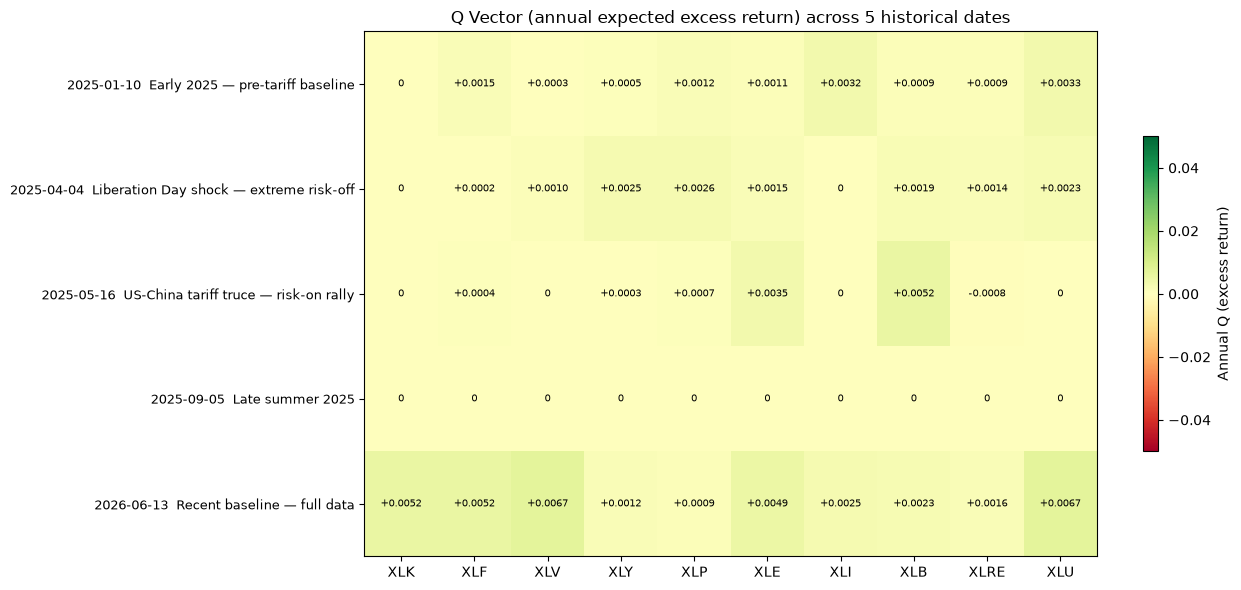


Macro regime per date (from signals table):
  2025-01-10  neutral   conf=0.58
  2025-04-04  risk_off  conf=0.88
  2025-05-16  risk_on   conf=0.72
  2025-09-05  risk_on   conf=0.72
  2026-06-13  risk_on   conf=0.72


In [11]:
# Q-vector heatmap across all 5 dates × 10 sectors
ok_runs = [(d, v) for d, v in pipeline_runs.items() if v['result'] is not None]

if not ok_runs:
    print('⚠  No successful pipeline runs to plot.')
else:
    import numpy as np

    dates_ok  = [d for d, _ in ok_runs]
    labels_ok = [v['label'] for _, v in ok_runs]
    q_matrix  = np.array([v['result']['views']['q'] for _, v in ok_runs])  # shape (n_dates, n_sectors)

    fig, ax = plt.subplots(figsize=(13, max(3, len(dates_ok) * 0.9 + 1.5)))
    # Q is in annual units after ADR-020; cap at ±5% (max_excess_return_annual)
    im = ax.imshow(q_matrix, aspect='auto', cmap='RdYlGn', vmin=-0.05, vmax=0.05)

    ax.set_xticks(range(len(SECTORS)))
    ax.set_xticklabels(SECTORS, fontsize=10)
    ax.set_yticks(range(len(dates_ok)))
    ax.set_yticklabels([f'{d}  {lbl}' for d, lbl in zip(dates_ok, labels_ok)], fontsize=9)
    ax.set_title('Q Vector (annual expected excess return) across 5 historical dates', fontsize=12)

    # Annotate each cell with the Q value
    for i in range(len(dates_ok)):
        for j in range(len(SECTORS)):
            val = q_matrix[i, j]
            txt = f'{val:+.4f}' if abs(val) > 1e-6 else '0'
            ax.text(j, i, txt, ha='center', va='center', fontsize=7,
                    color='black' if abs(val) < 0.03 else 'white')

    plt.colorbar(im, ax=ax, label='Annual Q (excess return)', shrink=0.6)
    plt.tight_layout()
    plt.show()

    # Regime labels side-by-side
    print('\nMacro regime per date (from signals table):')
    regime_map = {1.0: 'risk_on ▲', 0.0: 'neutral  ─', -1.0: 'risk_off ▼'}
    for d, v in ok_runs:
        macro = v['result']['signals_by_agent'].get('macro', {})
        if macro.get('status') == 'ok':
            regime_val = macro['result'].get('regime', 'n/a')
            conf = macro['result'].get('confidence', 0)
            print(f'  {d}  {regime_val:<8s}  conf={conf:.2f}')
        else:
            print(f'  {d}  (macro failed)')

## Section 10 — Sanity check: macro regime vs VIX

Do the regime labels issued by `MacroAgent` align with actual VIX levels on those dates?
Expected: `risk_off` dates should have the highest VIX; `risk_on` dates should have the lowest.

This is a necessary (not sufficient) sanity check — if the model labels COVID-crash as `risk_on`
something is badly wrong.

INFO matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Regime vs VIX summary:
  Date          Regime       Conf      VIX
  ────────────────────────────────────────
  2025-01-10    neutral      0.58     19.5
  2025-04-04    risk_off     0.88     45.3
  2025-05-16    risk_on      0.72     17.2
  2025-09-05    risk_on      0.72     15.2
  2026-06-13    risk_on      0.72     17.7


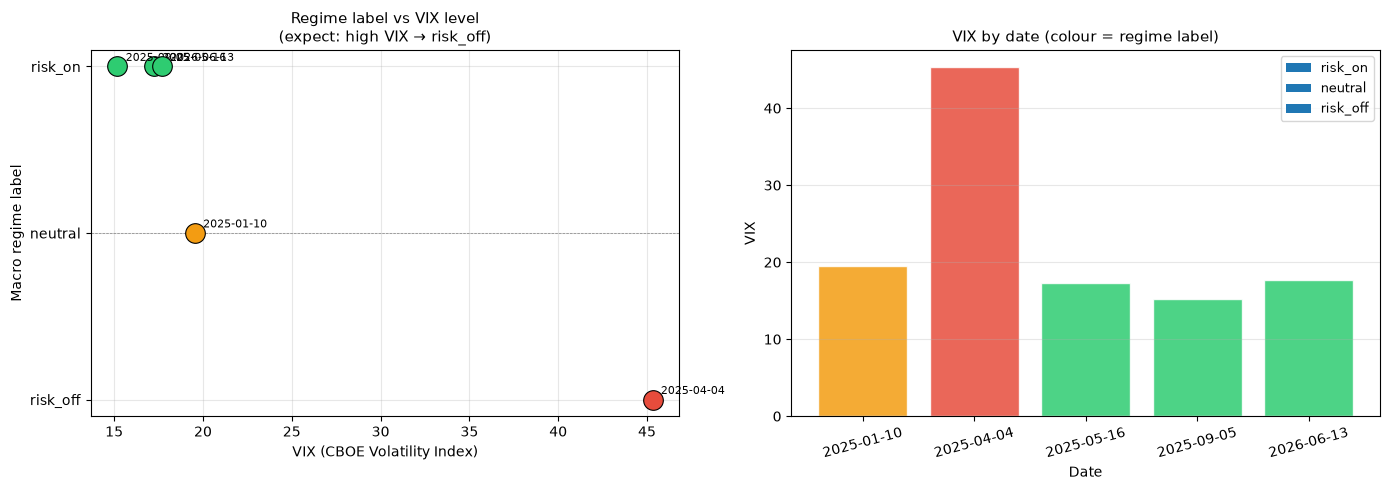


Sanity check: mean VIX(risk_off)=45.3 > mean VIX(risk_on)=16.7  →  ✓ PASS


In [12]:
# Pull regime signals and VIX levels for the 5 dates from the DB
regime_vix_df = pd.read_sql(
    text("""
        SELECT
            s.date,
            s.signal_value      AS regime_float,
            s.confidence        AS regime_conf,
            m.value             AS vix
        FROM signals s
        LEFT JOIN macro m
            ON m.date = s.date AND m.series_id = 'VIXCLS'
        WHERE s.agent_name = 'macro'
          AND s.target     = 'macro_regime'
        ORDER BY s.date
    """),
    engine,
    parse_dates=['date'],
)

if regime_vix_df.empty:
    print('⚠  No macro regime signals in DB — run Section 9 first.')
else:
    REGIME_LABEL = {1.0: 'risk_on', 0.0: 'neutral', -1.0: 'risk_off'}
    REGIME_COLOR = {1.0: '#2ecc71', 0.0: '#f39c12', -1.0: '#e74c3c'}

    regime_vix_df['regime'] = regime_vix_df['regime_float'].map(REGIME_LABEL)
    regime_vix_df['color']  = regime_vix_df['regime_float'].map(REGIME_COLOR)
    regime_vix_df['date_str'] = regime_vix_df['date'].dt.strftime('%Y-%m-%d')

    # Print summary table
    print('Regime vs VIX summary:')
    print(f'  {"Date":<12}  {"Regime":<10}  {"Conf":>5}  {"VIX":>7}')
    print('  ' + '─'*40)
    for _, row in regime_vix_df.iterrows():
        vix_str = f'{row["vix"]:.1f}' if pd.notna(row['vix']) else 'n/a'
        print(f'  {row["date_str"]:<12}  {row["regime"]:<10}  {row["regime_conf"]:>5.2f}  {vix_str:>7}')

    # Chart: VIX on x-axis, regime_float on y-axis, labelled by date
    has_vix = regime_vix_df['vix'].notna().any()
    if not has_vix:
        print('\n⚠  No VIX data in macro table for these dates.')
        print('   Run ingest_macro.py to populate historical FRED data.')
    else:
        fig, (ax_scatter, ax_bar) = plt.subplots(1, 2, figsize=(14, 5))

        # Left: scatter VIX vs regime
        for _, row in regime_vix_df.iterrows():
            if pd.notna(row['vix']):
                ax_scatter.scatter(row['vix'], row['regime_float'],
                                   color=row['color'], s=200, zorder=3,
                                   edgecolors='black', linewidths=0.8)
                ax_scatter.annotate(row['date_str'],
                                    (row['vix'], row['regime_float']),
                                    textcoords='offset points', xytext=(6, 4), fontsize=8)

        ax_scatter.set_yticks([-1, 0, 1])
        ax_scatter.set_yticklabels(['risk_off', 'neutral', 'risk_on'])
        ax_scatter.set_xlabel('VIX (CBOE Volatility Index)', fontsize=10)
        ax_scatter.set_ylabel('Macro regime label', fontsize=10)
        ax_scatter.set_title('Regime label vs VIX level\n(expect: high VIX → risk_off)', fontsize=11)
        ax_scatter.axhline(0, color='grey', linewidth=0.5, linestyle='--')
        ax_scatter.grid(alpha=0.3)

        # Right: VIX bar chart coloured by regime
        dates_with_vix = regime_vix_df[regime_vix_df['vix'].notna()]
        ax_bar.bar(dates_with_vix['date_str'], dates_with_vix['vix'],
                   color=dates_with_vix['color'], alpha=0.85, edgecolor='white')
        ax_bar.set_xlabel('Date', fontsize=10)
        ax_bar.set_ylabel('VIX', fontsize=10)
        ax_bar.set_title('VIX by date (colour = regime label)', fontsize=11)
        ax_bar.tick_params(axis='x', rotation=15)
        for ticker, color, label in [('#2ecc71', '#2ecc71', 'risk_on'),
                                      ('#f39c12', '#f39c12', 'neutral'),
                                      ('#e74c3c', '#e74c3c', 'risk_off')]:
            ax_bar.bar([], [], color=color, alpha=0.85, label=label)
        ax_bar.legend(fontsize=9)
        ax_bar.grid(axis='y', alpha=0.3)

        plt.tight_layout()
        plt.show()

        # Sanity verdict
        risk_off_rows = regime_vix_df[regime_vix_df['regime_float'] == -1.0]['vix'].dropna()
        risk_on_rows  = regime_vix_df[regime_vix_df['regime_float'] ==  1.0]['vix'].dropna()
        if len(risk_off_rows) > 0 and len(risk_on_rows) > 0:
            passes = risk_off_rows.mean() > risk_on_rows.mean()
            verdict = '✓ PASS' if passes else '✗ FAIL'
            print(f'\nSanity check: mean VIX(risk_off)={risk_off_rows.mean():.1f} > mean VIX(risk_on)={risk_on_rows.mean():.1f}  →  {verdict}')
        else:
            print('\n(Need at least one risk_off and one risk_on date to compare VIX means.)')

## Section 11 — Sanity check: news sentiment vs subsequent 1-week returns

For each (date, sector) pair, compare the sentiment signal to the sector ETF's return
over the following 5 trading days.  With only 5 dates × 10 sectors = 50 data points
a strong correlation is not expected — but a positive rank correlation (Spearman ρ > 0)
is the minimal bar for the signal to be "not noise".

Spearman rank correlation: ρ=0.235  p=0.144  →  ✓ PASS (ρ > 0)
(With 50 points and weekly data, weak correlation is expected.)


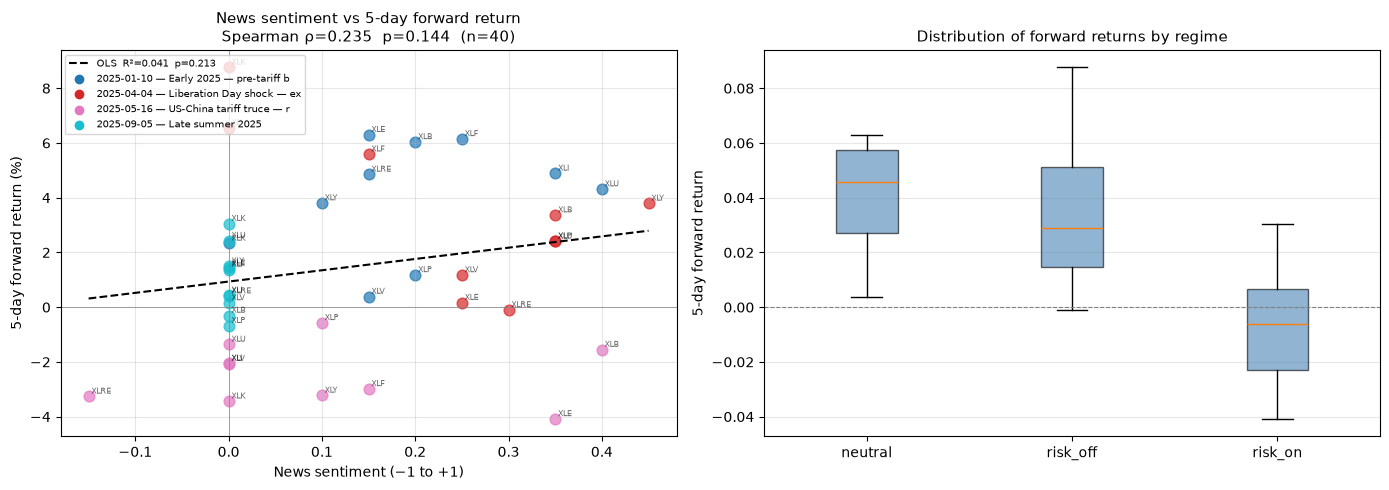

In [13]:
import numpy as np
from scipy import stats as scipy_stats

# Pull sentiment signals for our 5 dates
signal_dates = [d.isoformat() for d in pipeline_runs.keys()]

# Inline date values in SQL — safe because signal_dates are always YYYY-MM-DD strings
date_in_clause = "', '".join(signal_dates)
sentiment_df = pd.read_sql(
    text(f"""
        SELECT date, target AS sector, signal_value AS sentiment, confidence
        FROM signals
        WHERE agent_name = 'sentiment'
          AND date IN ('{date_in_clause}')
        ORDER BY date, target
    """),
    engine,
    parse_dates=['date'],
)

# Pull adj_close prices for forward-return calculation
price_df = pd.read_sql(
    text("SELECT date, ticker, adj_close FROM prices WHERE ticker IN ('XLK','XLF','XLV','XLY','XLP','XLE','XLI','XLB','XLRE','XLU') ORDER BY date"),
    engine,
    parse_dates=['date'],
)

if sentiment_df.empty or price_df.empty:
    print('⚠  No sentiment signals or price data — run Section 9 and ingest_prices.py first.')
    scatter_data = None
else:
    # Pivot prices to wide format (date × ticker)
    price_wide = price_df.pivot(index='date', columns='ticker', values='adj_close').sort_index()

    # For each (signal_date, sector): find return from signal_date to +5 trading days
    records = []
    for sig_date, group in sentiment_df.groupby('date'):
        sig_date_ts = pd.Timestamp(sig_date)
        # Find the 5-trading-day forward window
        future_dates = price_wide.index[price_wide.index > sig_date_ts]
        if len(future_dates) < 5:
            continue
        end_date = future_dates[4]

        for _, row in group.iterrows():
            sector = row['sector']
            if sector not in price_wide.columns:
                continue
            p0 = price_wide.loc[price_wide.index <= sig_date_ts, sector].iloc[-1] if (price_wide.index <= sig_date_ts).any() else None
            p1 = price_wide.loc[end_date, sector] if end_date in price_wide.index else None
            if p0 and p1 and p0 > 0:
                fwd_return = (p1 - p0) / p0
                records.append({'date': sig_date_ts, 'sector': sector,
                                 'sentiment': row['sentiment'], 'fwd_return_5d': fwd_return})

    scatter_data = pd.DataFrame(records)

if scatter_data is not None and not scatter_data.empty:
    fig, (ax_s, ax_c) = plt.subplots(1, 2, figsize=(14, 5))

    # Scatter: sentiment vs forward return, coloured by date
    date_colors = plt.cm.tab10(np.linspace(0, 1, scatter_data['date'].nunique()))
    date_color_map = {d: c for d, c in zip(sorted(scatter_data['date'].unique()), date_colors)}

    for _, row in scatter_data.iterrows():
        ax_s.scatter(row['sentiment'], row['fwd_return_5d'] * 100,
                     color=date_color_map[row['date']], alpha=0.7, s=60)

    # Regression line
    if len(scatter_data) >= 3:
        slope, intercept, r_value, p_value, _ = scipy_stats.linregress(
            scatter_data['sentiment'], scatter_data['fwd_return_5d'] * 100
        )
        rho, p_spearman = scipy_stats.spearmanr(scatter_data['sentiment'], scatter_data['fwd_return_5d'])
        x_line = np.linspace(scatter_data['sentiment'].min(), scatter_data['sentiment'].max(), 100)
        ax_s.plot(x_line, slope * x_line + intercept, 'k--', linewidth=1.5,
                  label=f'OLS  R²={r_value**2:.3f}  p={p_value:.3f}')
        ax_s.set_title(
            f'News sentiment vs 5-day forward return\n'
            f'Spearman ρ={rho:.3f}  p={p_spearman:.3f}  (n={len(scatter_data)})',
            fontsize=11)
        ax_s.legend(fontsize=9)

        verdict = '✓ PASS (ρ > 0)' if rho > 0 else '✗ FAIL (ρ ≤ 0)'
        print(f'Spearman rank correlation: ρ={rho:.3f}  p={p_spearman:.3f}  →  {verdict}')
        print('(With 50 points and weekly data, weak correlation is expected.)')
    else:
        ax_s.set_title('News sentiment vs 5-day forward return', fontsize=11)

    # Label selected points
    for _, row in scatter_data.iterrows():
        ax_s.annotate(row['sector'], (row['sentiment'], row['fwd_return_5d'] * 100),
                      fontsize=6, alpha=0.6, xytext=(2, 2), textcoords='offset points')

    ax_s.axhline(0, color='grey', linewidth=0.5)
    ax_s.axvline(0, color='grey', linewidth=0.5)
    ax_s.set_xlabel('News sentiment (−1 to +1)', fontsize=10)
    ax_s.set_ylabel('5-day forward return (%)', fontsize=10)
    ax_s.grid(alpha=0.3)

    # Legend for dates — format Timestamp as YYYY-MM-DD string for display
    for d, c in date_color_map.items():
        d_str = pd.Timestamp(d).strftime('%Y-%m-%d')
        lbl = pipeline_runs.get(pd.Timestamp(d).date(), {}).get('label', d_str)
        ax_s.scatter([], [], color=c, label=f'{d_str} — {lbl[:25]}')
    ax_s.legend(fontsize=7, loc='upper left')

    # Right: box plot of forward returns by regime
    sig_regime = pd.read_sql(
        text("SELECT date, signal_value AS regime FROM signals WHERE agent_name='macro' AND target='macro_regime'"),
        engine, parse_dates=['date'],
    )
    # Both scatter_data['date'] and sig_regime['date'] are datetime64 — merge directly
    scatter_regime = scatter_data.merge(sig_regime, on='date', how='left')
    REGIME_LABEL = {1.0: 'risk_on', 0.0: 'neutral', -1.0: 'risk_off'}
    scatter_regime['regime_label'] = scatter_regime['regime'].map(REGIME_LABEL).fillna('unknown')

    regime_groups = scatter_regime.groupby('regime_label')['fwd_return_5d'].apply(list).to_dict()
    regime_labels = list(regime_groups.keys())
    # 'labels' kwarg was renamed to 'tick_labels' in matplotlib 3.9; set separately for compatibility
    ax_c.boxplot(list(regime_groups.values()), patch_artist=True,
                 boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax_c.set_xticks(range(1, len(regime_labels) + 1))
    ax_c.set_xticklabels(regime_labels)
    ax_c.axhline(0, color='grey', linewidth=0.8, linestyle='--')
    ax_c.set_ylabel('5-day forward return', fontsize=10)
    ax_c.set_title('Distribution of forward returns by regime', fontsize=11)
    ax_c.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print('⚠  Insufficient data for sentiment vs returns check.')

## Section 12 — Cost analysis

Three sub-cells:
1. Per-run cost table for the 5 historical dates
2. Backtest cost projection (78 weeks at observed cost per run)
3. Cache hit rate — re-run one date and confirm cost drops to ~$0

Per-run LLM cost by agent (USD):


agent_name,events,macro,sentiment,total
call_date,,,,
2026-06-14,0.00000,0.00000,0.11312,0.11312
2026-06-21,0.03779,0.12399,0.06836,0.23014



Total cost (5 runs) : $0.34326
Cache hit rate      : 187/212 calls = 88.2%


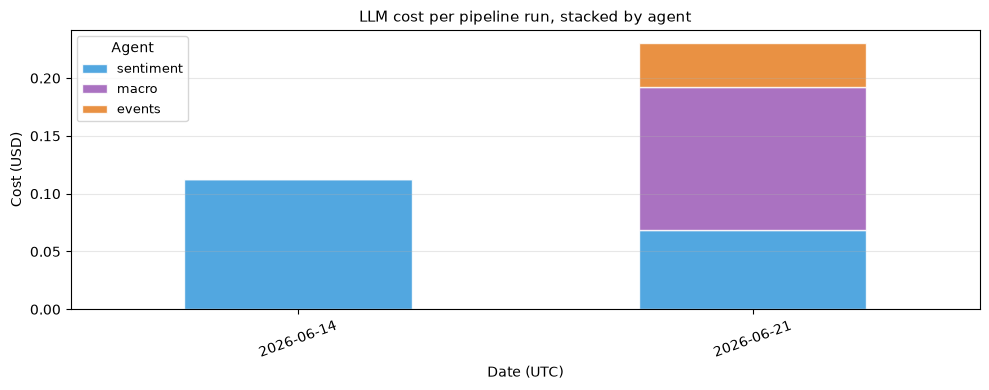

In [14]:
# ── 12a: Per-run cost breakdown from agent_calls ──────────────────────────────
cost_df = pd.read_sql(
    text("""
        SELECT
            date(timestamp)          AS call_date,
            agent_name,
            SUM(cost_usd)            AS cost_usd,
            SUM(tokens_in)           AS tokens_in,
            SUM(tokens_out)          AS tokens_out,
            COUNT(*)                 AS calls,
            SUM(CASE WHEN cached=1 THEN 1 ELSE 0 END) AS cache_hits
        FROM agent_calls
        GROUP BY date(timestamp), agent_name
        ORDER BY call_date, agent_name
    """),
    engine,
)

if cost_df.empty:
    print('⚠  No agent_calls rows yet — run Section 9 first.')
else:
    # Pivot to (date × agent) grid
    cost_pivot = cost_df.pivot_table(
        index='call_date', columns='agent_name', values='cost_usd', aggfunc='sum', fill_value=0
    )
    cost_pivot['total'] = cost_pivot.sum(axis=1)

    print('Per-run LLM cost by agent (USD):')
    display(cost_pivot.round(5))

    total_cost = cost_df['cost_usd'].sum()
    total_calls = cost_df['calls'].sum()
    total_cache_hits = cost_df['cache_hits'].sum()
    hit_rate = total_cache_hits / total_calls * 100 if total_calls > 0 else 0

    print(f'\nTotal cost (5 runs) : ${total_cost:.5f}')
    print(f'Cache hit rate      : {total_cache_hits}/{total_calls} calls = {hit_rate:.1f}%')

    # Bar chart: cost per date, stacked by agent
    agents_in_pivot = [c for c in ['sentiment', 'macro', 'events'] if c in cost_pivot.columns]
    colors_by_agent = {'sentiment': '#3498db', 'macro': '#9b59b6', 'events': '#e67e22'}
    ax = cost_pivot[agents_in_pivot].plot(
        kind='bar', stacked=True, figsize=(10, 4),
        color=[colors_by_agent.get(a, 'grey') for a in agents_in_pivot],
        alpha=0.85, edgecolor='white',
    )
    ax.set_xlabel('Date (UTC)', fontsize=10)
    ax.set_ylabel('Cost (USD)', fontsize=10)
    ax.set_title('LLM cost per pipeline run, stacked by agent', fontsize=11)
    ax.tick_params(axis='x', rotation=20)
    ax.legend(title='Agent', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

Average first-run cost per pipeline run: $0.17163

Projected backtest cost (78 weekly dates):
  Scenario           Cost/run         Total
  ──────────────────────────────────────────
  Optimistic       $  0.08581  $     6.6935
  Base             $  0.17163  $    13.3870
  Pessimistic      $  0.34326  $    26.7740

  Note: repeated runs use the SHA256 file cache → cost ≈ $0 after first pass.
  Only genuine cache misses (new dates or changed prompts) incur API charges.


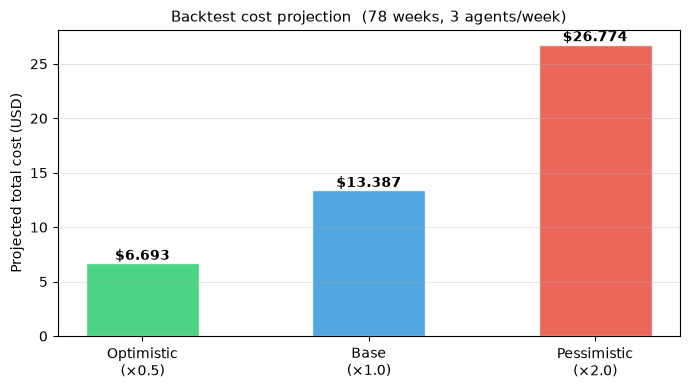

In [15]:
# ── 12b: Backtest cost projection ────────────────────────────────────────────
if not cost_df.empty:
    # Average non-zero cost per run (exclude cache-hit-only runs)
    run_costs = cost_df.groupby('call_date')['cost_usd'].sum()
    non_zero = run_costs[run_costs > 0]

    if non_zero.empty:
        print('All observed costs are $0 (all cache hits) — cannot project from live runs.')
        print('Expected first-run cost: ~$0.005–$0.02 per pipeline run.')
        avg_cost_per_run = 0.01  # use rough estimate
    else:
        avg_cost_per_run = non_zero.mean()
        print(f'Average first-run cost per pipeline run: ${avg_cost_per_run:.5f}')

    # Backtest parameters
    BACKTEST_WEEKS = 78          # 18 months of weekly rebalances
    SENSITIVITY_MULTIPLIERS = [0.5, 1.0, 2.0]  # optimistic / base / pessimistic

    print(f'\nProjected backtest cost ({BACKTEST_WEEKS} weekly dates):')
    print(f'  {"Scenario":<15}  {"Cost/run":>10}  {"Total":>12}')
    print('  ' + '─'*42)
    for mult in SENSITIVITY_MULTIPLIERS:
        name = {0.5: 'Optimistic', 1.0: 'Base', 2.0: 'Pessimistic'}[mult]
        cost_per = avg_cost_per_run * mult
        total = cost_per * BACKTEST_WEEKS
        print(f'  {name:<15}  ${cost_per:>9.5f}  ${total:>11.4f}')

    print(f'\n  Note: repeated runs use the SHA256 file cache → cost ≈ $0 after first pass.')
    print(f'  Only genuine cache misses (new dates or changed prompts) incur API charges.')

    # Visualise
    scenarios = ['Optimistic\n(×0.5)', 'Base\n(×1.0)', 'Pessimistic\n(×2.0)']
    totals = [avg_cost_per_run * m * BACKTEST_WEEKS for m in SENSITIVITY_MULTIPLIERS]
    colors = ['#2ecc71', '#3498db', '#e74c3c']

    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(scenarios, totals, color=colors, alpha=0.85, edgecolor='white', width=0.5)
    for bar, val in zip(bars, totals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                f'${val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_ylabel('Projected total cost (USD)', fontsize=10)
    ax.set_title(f'Backtest cost projection  ({BACKTEST_WEEKS} weeks, 3 agents/week)', fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

In [16]:
# ── 12c: Cache hit rate verification ─────────────────────────────────────────
# Re-run the pipeline for one date.  All three agent calls should now be cache hits.
# The SHA256 key is deterministic: same (model, prompt, input_data) → same key → $0 cost.

VERIFY_DATE = datetime.date(2026, 6, 13)

print(f'Re-running pipeline for {VERIFY_DATE} (should hit cache for all agents)...')
baseline_max_call_id = pd.read_sql(text("SELECT MAX(call_id) FROM agent_calls"), engine).iloc[0, 0] or 0

rerun_result = run_agent_pipeline(VERIFY_DATE, engine)

# Inspect only the agent_calls rows created by THIS re-run
new_calls_df = pd.read_sql(
    text(f"SELECT agent_name, cached, cost_usd, latency_ms FROM agent_calls WHERE call_id > {baseline_max_call_id} ORDER BY call_id"),
    engine,
)

if new_calls_df.empty:
    print('No new agent_calls rows (pipeline returned all-error or no LLM agents ran).')
else:
    new_calls_df['cached'] = new_calls_df['cached'].map({1: '✓ hit', 0: '✗ miss', None: '—'})
    new_calls_df['cost_usd'] = new_calls_df['cost_usd'].map(lambda x: f'${x:.6f}' if pd.notna(x) else '—')
    new_calls_df['latency_ms'] = new_calls_df['latency_ms'].map(lambda x: f'{x:.0f} ms' if pd.notna(x) else '—')
    print('\nNew agent_calls rows from re-run:')
    display(new_calls_df.rename(columns={'agent_name': 'agent', 'cached': 'cache', 'cost_usd': 'cost', 'latency_ms': 'latency'}))

rerun_cost = rerun_result['total_cost_usd']
print(f'\nRe-run total cost   : ${rerun_cost:.6f}')
print(f'Re-run total latency: {rerun_result["total_latency_ms"]:.0f} ms')

if rerun_cost < 0.0001:
    print('\n✓ Cache verification PASSED — re-run cost ≈ $0 (all hits)')

INFO agents.pipeline: === run_agent_pipeline  date=2026-06-13 ===
INFO agents.news_agent: prepare_input date=2026-06-13  total_articles=200  sectors=10
INFO cache: agent=sentiment            model=claude-haiku-4-5-20251001      cached=True   in=    0 out=    0  cost=$0.00000  latency=0ms
INFO agents.news_agent: Wrote 10 signal rows  date=2026-06-13  agent=sentiment  avg_conviction=0.55
INFO agents.pipeline: Agent sentiment succeeded  latency=22ms


Re-running pipeline for 2026-06-13 (should hit cache for all agents)...


INFO agents.macro_agent: prepare_input date=2026-06-13  macro_rows=2807  news_articles=13
INFO cache: agent=macro                model=claude-sonnet-4-6              cached=True   in=    0 out=    0  cost=$0.00000  latency=3ms
INFO agents.macro_agent: Wrote 2 signal rows  date=2026-06-13  regime=risk_on  rate_outlook=stable  confidence=0.72
INFO agents.pipeline: Agent macro succeeded  latency=106ms
INFO agents.polymarket_agent: prepare_input date=2026-06-13  markets_with_data=13/13
INFO cache: agent=events               model=claude-haiku-4-5-20251001      cached=True   in=    0 out=    0  cost=$0.00000  latency=0ms
INFO agents.polymarket_agent: Wrote 10 signal rows  date=2026-06-13  agent=events  confidence=0.58
INFO agents.pipeline: Agent events succeeded  latency=6ms
INFO aggregator.views: build_views date=2026-06-13  mode=live  |Q|_max=0.00668  regime=1.0  scale=1.00  sectors=10
INFO agents.pipeline: Pipeline complete  date=2026-06-13  cost=$0.00000  latency=150ms  failed=none



New agent_calls rows from re-run:


,agent,cache,cost,latency
0,sentiment,✓ hit,$0.000000,0 ms
1,macro,✓ hit,$0.000000,3 ms
2,events,✓ hit,$0.000000,0 ms



Re-run total cost   : $0.000000
Re-run total latency: 150 ms

✓ Cache verification PASSED — re-run cost ≈ $0 (all hits)
